<a href="https://colab.research.google.com/github/shanusushmita/CS-6140-Machine-Learning-Course-/blob/main/NLP_Sentiment_Analysis_IMDB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

![Example image](https://upload.wikimedia.org/wikipedia/commons/0/02/Northeastern_Wordmark.svg)

## Sentiment Analysis

Copyright: Prof. Shanu Sushmita

<>:24: SyntaxWarning: invalid escape sequence '\.'
<>:24: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-3121463601.py:24: SyntaxWarning: invalid escape sequence '\.'
  pattern1 = re.compile("<br /><br />|\.")
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Preprocessing text using custom structural patterns...


/tmp/ipython-input-3121463601.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=train_labels, palette="viridis")


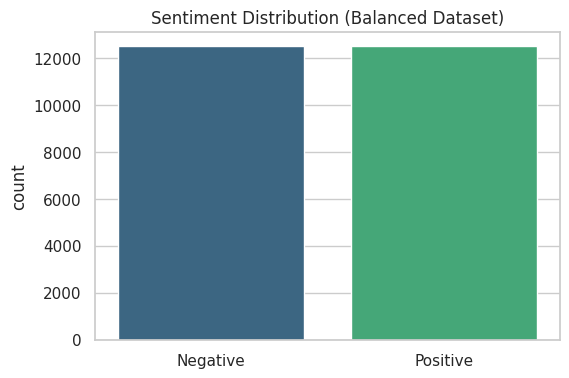

Accuracy: 0.8890


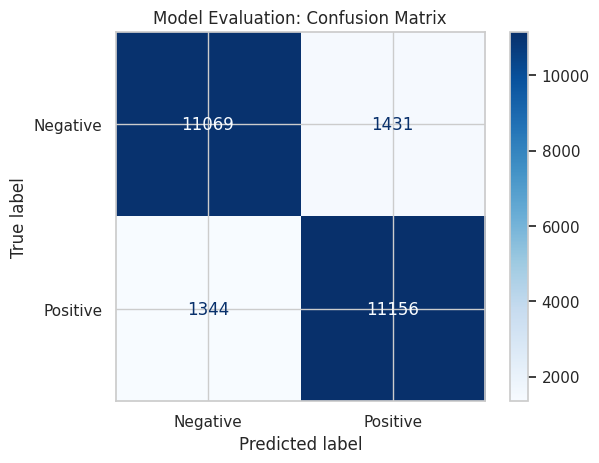


Sample Test: 'I absolutely loved this film! The acting was superb.' -> Prediction: Positive


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from nltk.corpus import stopwords
import nltk

# Ensure stopwords are available
nltk.download('stopwords')
all_stopwords = set(stopwords.words('english'))

# 1. Load Dataset
dataset = load_dataset("stanfordnlp/imdb")
df_train = dataset['train'].to_pandas()

# 2. Custom Pre-processing Logic
def custom_clean_text(text):
    # Pattern for HTML line breaks and full stops as structural splitters
    pattern1 = re.compile("<br /><br />|\.")
    lines = re.split(pattern1, text)

    tokens = []
    for line in lines:
        # Whitespace based split
        tokens += line.split(" ")

    # Lowercase and remove non-alphanumeric characters for normalization [cite: 72]
    normalized_tokens = [re.sub(r"\W+", "", token.lower()) for token in tokens]

    # Return joined tokens, filtering for stopwords and length [cite: 72]
    return " ".join([
        token
        for token in normalized_tokens
        if token and token not in all_stopwords and len(tokens) > 1
    ])

print("Preprocessing text using custom structural patterns...")
train_texts = [custom_clean_text(x) for x in dataset['train']['text']]
test_texts = [custom_clean_text(x) for x in dataset['test']['text']]
train_labels = dataset['train']['label']
test_labels = dataset['test']['label']

# 3. Visualizations

# Distribution of Sentiments
plt.figure(figsize=(6, 4))
sns.countplot(x=train_labels, palette="viridis")
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Sentiment Distribution (Balanced Dataset)')
plt.show()


# 4. Feature Extraction (TF-IDF)
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2))
X_train = tfidf.fit_transform(train_texts)
X_test = tfidf.transform(test_texts)

# 5. Classification
model = LogisticRegression(max_iter=1000)
model.fit(X_train, train_labels)

# 6. Evaluation & Results
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(test_labels, y_pred):.4f}")

# Confusion Matrix
cm = confusion_matrix(test_labels, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Model Evaluation: Confusion Matrix')
plt.show()

# 7. Practical Test
sample_review = "I absolutely loved this film! The acting was superb."
cleaned_sample = clean_text(sample_review)
sample_vec = tfidf.transform([cleaned_sample])
prediction = model.predict(sample_vec)[0]
sentiment = "Positive" if prediction == 1 else "Negative"
print(f"\nSample Test: '{sample_review}' -> Prediction: {sentiment}")

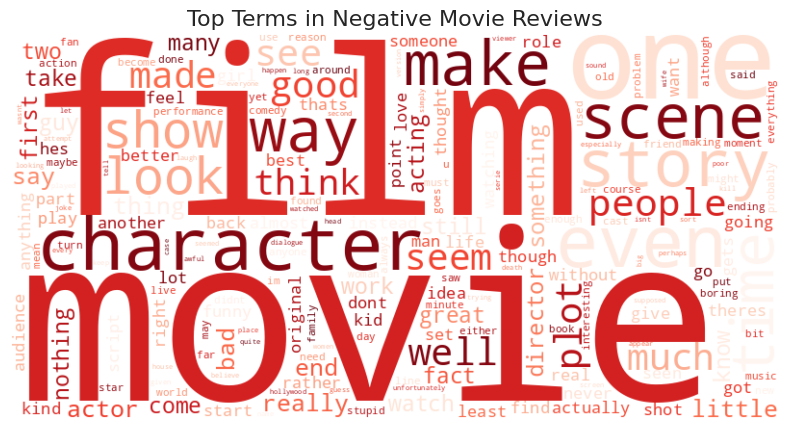

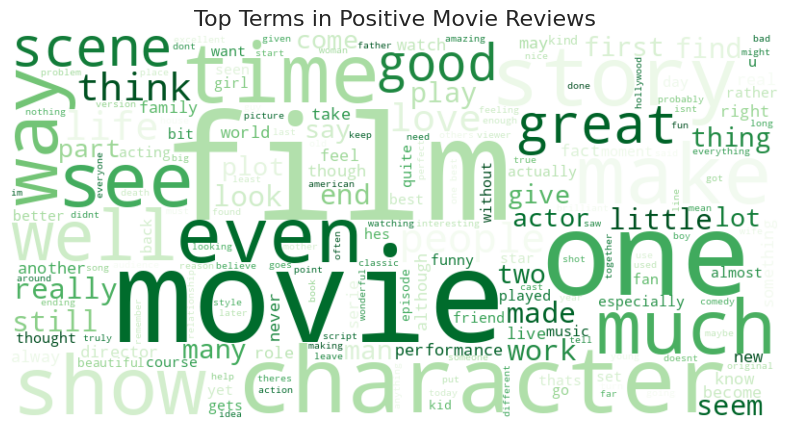

In [ ]:
# 3. Visualizations: Positive and Negative Word Clouds

def generate_wc(label_idx, title, color_map):
    # Filter processed text by label
    text_subset = " ".join([train_texts[i] for i, l in enumerate(train_labels) if l == label_idx])
    wc = WordCloud(width=800, height=400, background_color='white', colormap=color_map).generate(text_subset)

    plt.figure(figsize=(10, 5))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# Generate Cloud for Negative Sentiment (Label 0)
generate_wc(0, "Top Terms in Negative Movie Reviews", "Reds")

# Generate Cloud for Positive Sentiment (Label 1)
generate_wc(1, "Top Terms in Positive Movie Reviews", "Greens")

### Punctuation Intensity (Exclamation Marks)

/tmp/ipython-input-1977906454.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_train, x='label', y='excl_count', palette=['red', 'green'])


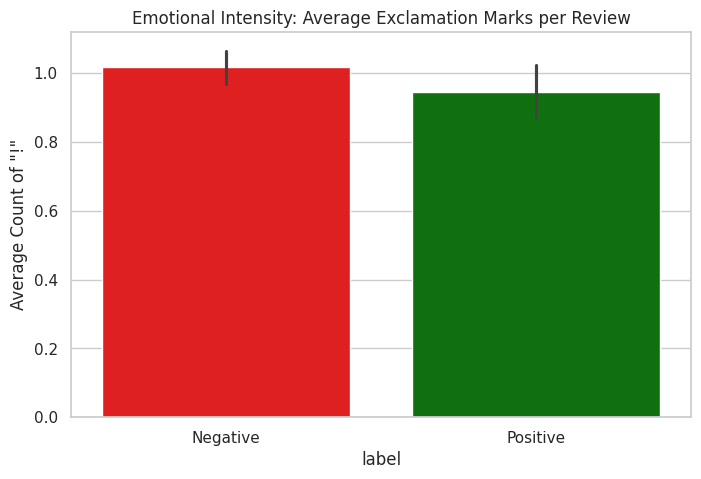

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate '!' counts for each review
df_train['excl_count'] = df_train['text'].apply(lambda x: x.count('!'))

# Plot the average intensity by sentiment
plt.figure(figsize=(8, 5))
sns.barplot(data=df_train, x='label', y='excl_count', palette=['red', 'green'])
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Emotional Intensity: Average Exclamation Marks per Review')
plt.ylabel('Average Count of "!"')
plt.show()

### Lexical Diversity (Type-Token Ratio)

This metric measures the "richness" of a reviewer's vocabulary by looking at the ratio of unique words to the total word count. It helps you see if positive or negative feedback tends to be more repetitive.

/tmp/ipython-input-1851992358.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x='label', y='diversity', palette='Set2')


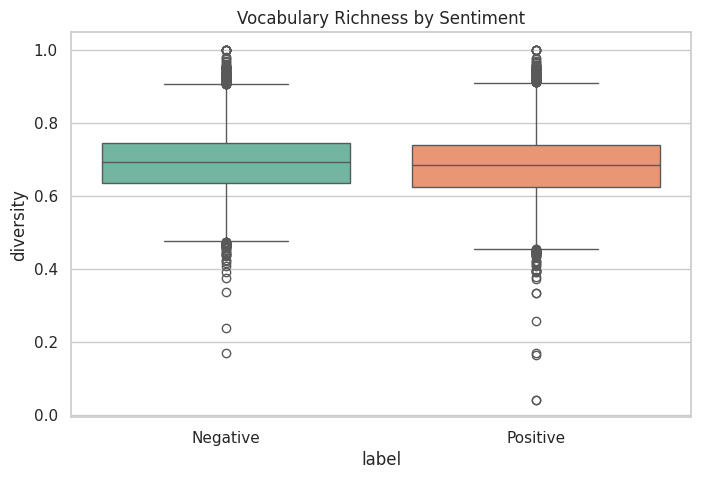

In [ ]:
def lexical_diversity(text):
    words = text.lower().split()
    if len(words) == 0: return 0
    return len(set(words)) / len(words)

df_train['diversity'] = df_train['text'].apply(lexical_diversity)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_train, x='label', y='diversity', palette='Set2')
plt.xticks([0, 1], ['Negative', 'Positive'])
plt.title('Vocabulary Richness by Sentiment')
plt.show()

### Common Phrases (Bigram Analysis)

While word clouds show individual words, Bigrams (pairs of words) reveal the context of sentiment. This is particularly useful for identifying common complaints or praises.

In [ ]:
from collections import Counter
import re

def get_top_bigrams_cleaned(texts, n=15):
    all_bigrams = []

    for text in texts:
        # 1. Use your custom structural pre-processing first
        # This ensures <br /><br /> and '.' are treated as boundaries
        pattern1 = re.compile("<br /><br />|\.")
        lines = re.split(pattern1, text)

        # 2. Extract tokens exactly like your 'custom_clean_text' function
        tokens = []
        for line in lines:
            # Whitespace split
            line_tokens = line.split(" ")
            # Normalize: lowercase and remove non-alphanumeric
            normalized = [re.sub(r"\W+", "", t.lower()) for t in line_tokens]
            # Filter based on your rules (stop words and empty strings)
            clean_tokens = [t for t in normalized if t and t not in all_stopwords]
            tokens.extend(clean_tokens)

        # 3. Create Bigrams from the cleaned token list
        # zip(tokens, tokens[1:]) creates pairs: (w1, w2), (w2, w3)...
        all_bigrams.extend(zip(tokens, tokens[1:]))

    return Counter(all_bigrams).most_common(n)

# Executing for both classes
pos_bigrams = get_top_bigrams_cleaned(df_train[df_train['label']==1]['text'])
neg_bigrams = get_top_bigrams_cleaned(df_train[df_train['label']==0]['text'])

# Print results formatted for a slide
print("--- Top Cleaned Positive Bigrams ---")
for (bi, count) in pos_bigrams:
    print(f"{bi[0]} {bi[1]}: {count}")

print("\n--- Top Cleaned Negative Bigrams ---")
for (bi, count) in neg_bigrams:
    print(f"{bi[0]} {bi[1]}: {count}")

<>:10: SyntaxWarning: invalid escape sequence '\.'
<>:10: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1210692671.py:10: SyntaxWarning: invalid escape sequence '\.'
  pattern1 = re.compile("<br /><br />|\.")


--- Top Cleaned Positive Bigrams ---
one best: 777
even though: 564
ive seen: 545
first time: 483
ever seen: 482
new york: 466
dont know: 452
special effects: 409
years ago: 376
see movie: 372
good movie: 349
great movie: 328
well done: 323
real life: 303
im sure: 302

--- Top Cleaned Negative Bigrams ---
ever seen: 826
waste time: 737
special effects: 672
looks like: 623
ive seen: 609
dont know: 581
much better: 497
one worst: 477
even though: 457
im sure: 434
bad movie: 433
look like: 428
ive ever: 416
low budget: 403
see movie: 382


### Structural Analysis (Sentence Counts)

We can measure the average "length of thought" (sentences per review).

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/tmp/ipython-input-1712999607.py:2: SyntaxWarning: invalid escape sequence '\.'
  pattern1 = re.compile("<br /><br />|\.")


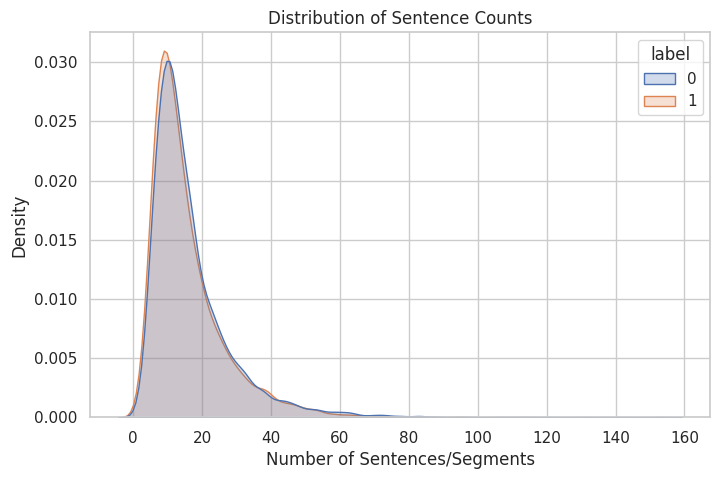

In [ ]:
# Using our pattern-based splitter
pattern1 = re.compile("<br /><br />|\.")

df_train['sentence_count'] = df_train['text'].apply(lambda x: len(re.split(pattern1, x)))

plt.figure(figsize=(8, 5))
sns.kdeplot(data=df_train, x='sentence_count', hue='label', fill=True)
plt.title('Distribution of Sentence Counts')
plt.xlabel('Number of Sentences/Segments')
plt.show()